### Train the VAE

In [19]:
import lightning as l
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, Callback

from datasets import WDBCDataModule
from l_modules import VAEModule
import torch

In [ ]:
SEED = 42
BATCH_SIZE = 32
INPUT_DIM = 30
LABEL_DIM = 2
LATENT_DIM = 16
MAX_EPOCHS = 500
VERSION = "conditional_vae_v2"

l.seed_everything(SEED)

Seed set to 42


42

In [21]:
class InjectNormStats(Callback):
    def on_fit_start(self, trainer, pl_module):
        dm = trainer.datamodule
        pl_module.feature_mean = torch.tensor(dm.feature_mean, dtype=torch.float32).to(pl_module.device)
        pl_module.feature_std = torch.tensor(dm.feature_std, dtype=torch.float32).to(pl_module.device)


In [24]:
import os, glob

data_module = WDBCDataModule(batch_size=BATCH_SIZE, seed=SEED)
model = VAEModule(feature_dim=INPUT_DIM, label_dim=LABEL_DIM, latent_dim=LATENT_DIM, beta_max=1.0, beta_warmup_epochs=20)

logger = CSVLogger(save_dir="logs", name="vae_training", version=VERSION)

# Remove old checkpoint so ModelCheckpoint doesn't version-suffix
for f in glob.glob(os.path.join(logger.log_dir, "best_model*.ckpt")):
    os.remove(f)

callbacks = [
    EarlyStopping(monitor="train_loss", patience=50, mode="min"),
    ModelCheckpoint(
        dirpath=logger.log_dir,
        monitor="train_loss",
        mode="min",
        save_top_k=1,
        filename="best_model",
    ),
    InjectNormStats(),
]

trainer = l.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",
    log_every_n_steps=1,
    logger=logger,
    callbacks=callbacks,
)

trainer.fit(model, data_module)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/toga/miniconda3/envs/ds/lib/python3.11/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory logs/vae_training/conditional_vae_v1 exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/Users/toga/miniconda3/envs/ds/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/toga/DS4420_Project/logs/vae_training/conditional_vae_v1 exists and is not empty.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │ 49.6 K │ train │     0 │
│ 1 │ mu_layer     │ Linear     │  1.0 K │ train │     0 │
│ 2 │ logvar_layer │ Linear     │  1.0 K │ train │     0 │
│ 3 │ decoder      │ Sequential │ 50.3 K │ train │     0 │
│   │ other params │ n/a        │     64 │ n/a   │   n/a │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 102 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 102 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 23                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/toga/miniconda3/envs/ds/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/Users/toga/miniconda3/envs/ds/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:
434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of 
the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/toga/miniconda3/envs/ds/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:
434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of 
the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

### Training & Validation Curves

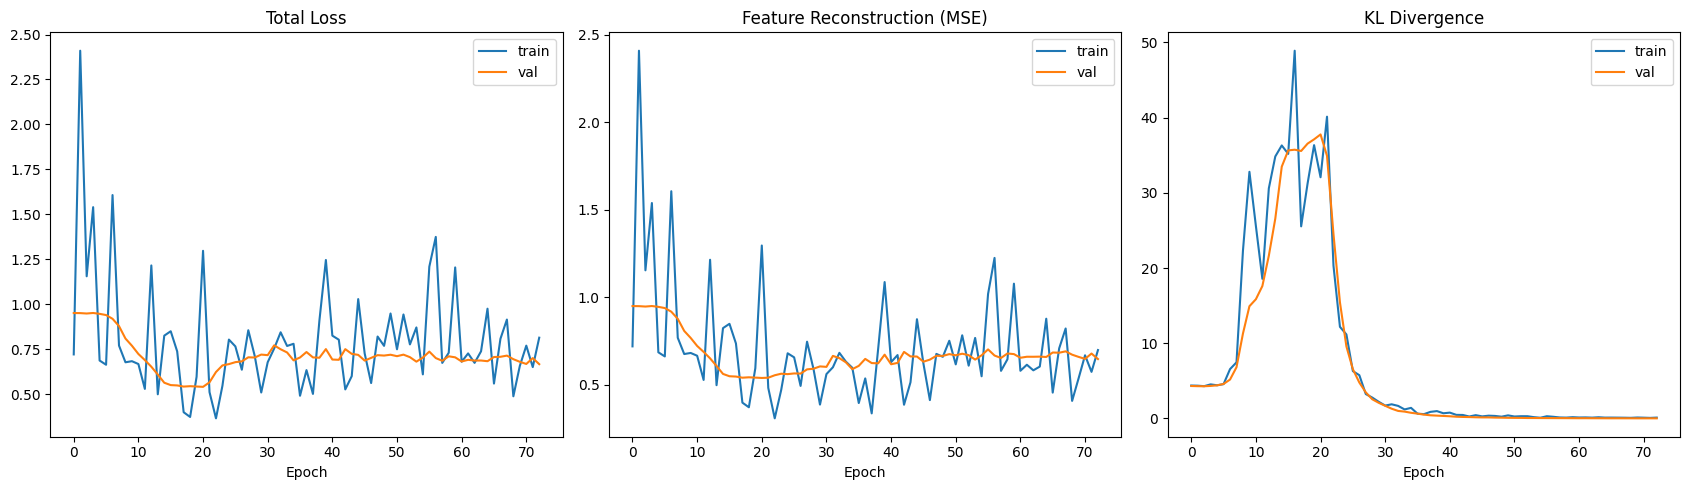

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")

# CSVLogger writes train and val metrics on separate rows per step,
# so we collapse them per epoch
train = metrics.dropna(subset=["train_loss"]).groupby("epoch").last()
val = metrics.dropna(subset=["val_loss"]).groupby("epoch").last()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Total loss
axes[0].plot(train.index, train["train_loss"], label="train")
axes[0].plot(val.index, val["val_loss"], label="val")
axes[0].set_title("Total Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# Feature reconstruction (MSE)
axes[1].plot(train.index, train["train_recon_cont"], label="train")
axes[1].plot(val.index, val["val_recon_cont"], label="val")
axes[1].set_title("Feature Reconstruction (MSE)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

# KL divergence
axes[2].plot(train.index, train["train_kl_div"], label="train")
axes[2].plot(val.index, val["val_kl_div"], label="val")
axes[2].set_title("KL Divergence")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()

plots_dir = os.path.join(logger.log_dir, "plots")
os.makedirs(plots_dir, exist_ok=True)
fig.savefig(os.path.join(plots_dir, "training_curves.png"), dpi=150)

plt.show()

In [26]:
model.prior_mu

Parameter containing:
tensor([[-0.0635,  0.3131,  0.1710, -0.2017, -0.8781, -1.2812, -0.0260,  0.7241,
         -0.2443,  0.4691,  0.5315,  0.1746, -0.5734,  1.4151,  1.0713, -0.3966],
        [-0.5845,  1.1457, -0.2071, -0.2311, -0.9412, -0.8870,  0.9664,  0.1230,
          0.2330,  0.3118,  1.0161, -0.5810,  0.3363, -0.4598,  0.5151, -1.2296]],
       requires_grad=True)

### Latent Space Visualization

/Users/toga/miniconda3/envs/ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


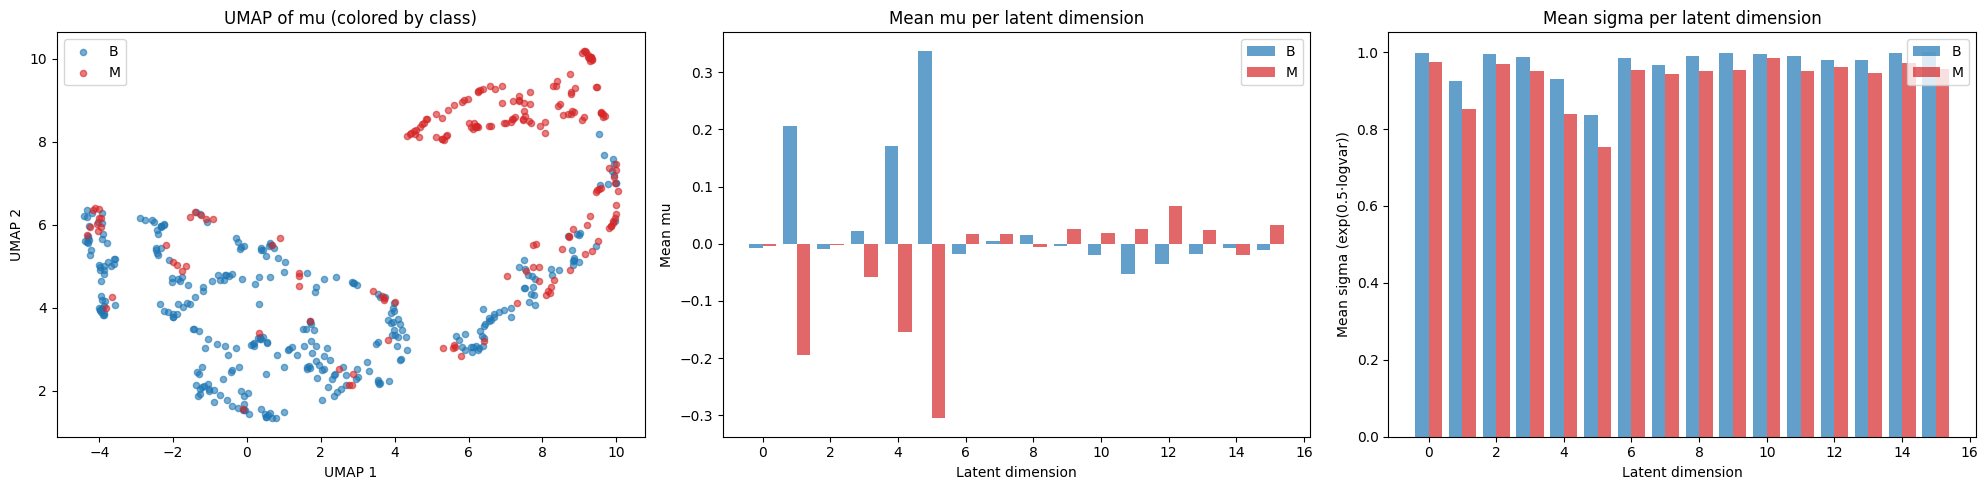

In [40]:
import torch
import numpy as np
import umap

model.eval()
data_module.setup()
all_X = torch.cat([data_module.train_X, data_module.val_X])
all_y = torch.cat([data_module.train_y, data_module.val_y])

with torch.no_grad():
    mu, logvar = model.encode(all_X.float(), all_y.unsqueeze(1).float())
    mu = mu.numpy()
    logvar = logvar.numpy()
    std = np.exp(0.5 * logvar)

all_y = all_y.numpy()
labels = ["B" if y == 0 else "M" for y in all_y]

# UMAP projection of mu
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
mu_2d = reducer.fit_transform(mu)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) UMAP of mu colored by class
for label, color in [("B", "tab:blue"), ("M", "tab:red")]:
    mask = np.array(labels) == label
    axes[0].scatter(mu_2d[mask, 0], mu_2d[mask, 1], c=color, label=label, alpha=0.6, s=20)
axes[0].set_title("UMAP of mu (colored by class)")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[0].legend()

# 2) Mean mu per dimension by class
benign_mu = mu[np.array(all_y) == 0].mean(axis=0)
malign_mu = mu[np.array(all_y) == 1].mean(axis=0)
x_dims = np.arange(mu.shape[1])
axes[1].bar(x_dims - 0.2, benign_mu, width=0.4, label="B", color="tab:blue", alpha=0.7)
axes[1].bar(x_dims + 0.2, malign_mu, width=0.4, label="M", color="tab:red", alpha=0.7)
axes[1].set_title("Mean mu per latent dimension")
axes[1].set_xlabel("Latent dimension")
axes[1].set_ylabel("Mean mu")
axes[1].legend()

# 3) Mean std per dimension by class
benign_std = std[np.array(all_y) == 0].mean(axis=0)
malign_std = std[np.array(all_y) == 1].mean(axis=0)
axes[2].bar(x_dims - 0.2, benign_std, width=0.4, label="B", color="tab:blue", alpha=0.7)
axes[2].bar(x_dims + 0.2, malign_std, width=0.4, label="M", color="tab:red", alpha=0.7)
axes[2].set_title("Mean sigma per latent dimension")
axes[2].set_xlabel("Latent dimension")
axes[2].set_ylabel("Mean sigma (exp(0.5·logvar))")
axes[2].legend()

plt.tight_layout()

fig.savefig(os.path.join(plots_dir, "latent_space.png"), dpi=150)
plt.show()

In [41]:
new_samples, new_y = model.generate(n_samples=10)
new_samples = new_samples.cpu().numpy()
new_y = new_y.cpu().numpy()